# redistance_circles

Saini et al. (2026) §4.4: the re-distancing equation, Eq. (44), solved
**standalone**. There is no flow and no phase field, only a pseudo-time relaxation
of the skewed initial condition Eq. (83) toward the exact distance function
around two intersecting circles, run to $\tau = 6$.

It uses the authors' configuration, from their public case: BDF2/EXT2
(Eqs. 34–35), the Eq. (31) SVV left-multiplied by $|\operatorname{sgn}\psi|$, a
fixed sign-function $\varepsilon = 0.25$ in Eq. (46), a dealiased
$\mathbf C(\mathbf w)\psi$, and their sign guard. Two Table 2 cells at $N=3$,
from the shipped runs:

* $H = 1/10$: $E_r$, Eq. (84) as printed, is 0.978× their value.
* $H = 1/20$: 1.011× their value. The steep-side cone apex at $(-0.7, 0)$ holds.

The white contour is the computed $\psi = 0$; the dashed black one is the exact
$\psi_e = 0$. The case's `README.md` describes the configuration, the results over
the whole grid, and the limitations.


In [1]:
import glob, logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpi4py import MPI
from pysemtools.io.ppymech.neksuite import preadnek
from pysemtools.datatypes.msh import Mesh as msh_c
from pysemtools.datatypes.field import Field as field_c
from pysemtools.datatypes.coef import Coef

logging.disable(logging.INFO)
comm = MPI.COMM_WORLD
A, R = 0.7, 1.0
HC = np.sqrt(R*R - A*A)

def psi_exact(x, y):
    """Eq. (83): signed distance to the union of the two circles, negative
    inside. The first branch is the corner-clamped case along the kink."""
    d1, d2 = np.hypot(x - A, y), np.hypot(x + A, y)
    corner = ((A - x) >= (A/R)*d1) & ((A + x) >= (A/R)*d2)
    return np.where(corner,
                    -np.minimum(np.hypot(x, y - HC), np.hypot(x, y + HC)),
                    np.minimum(d1, d2) - R)

def load(outdir):
    """The single relaxed frame this case writes, plus Eq. (84)'s E_r.

    E_r must be a GLL-quadrature integral, not a nodal mean -- the GLL weights
    vary by an order of magnitude across an element, so an unweighted average is
    a different (and wrong) number. B is the mass matrix; the slab's uniform
    thickness cancels in the ratio, so no z-correction is needed.
    """
    f = sorted(glob.glob(f"{outdir}/field0.f?????"))[-1]
    d = preadnek(f, comm)
    m = msh_c(comm, data=d)
    B = Coef(m, comm).B
    psi = field_c(comm, data=d).fields["temp"][0]
    pe = psi_exact(m.x, m.y)
    er = (B*np.abs(psi - pe)).sum() / (B*pe).sum()
    iz = m.z.shape[1]//2
    tri = mtri.Triangulation(m.x[:, iz, :, :].ravel(), m.y[:, iz, :, :].ravel())
    return tri, psi[:, iz, :, :].ravel(), pe[:, iz, :, :].ravel(), er


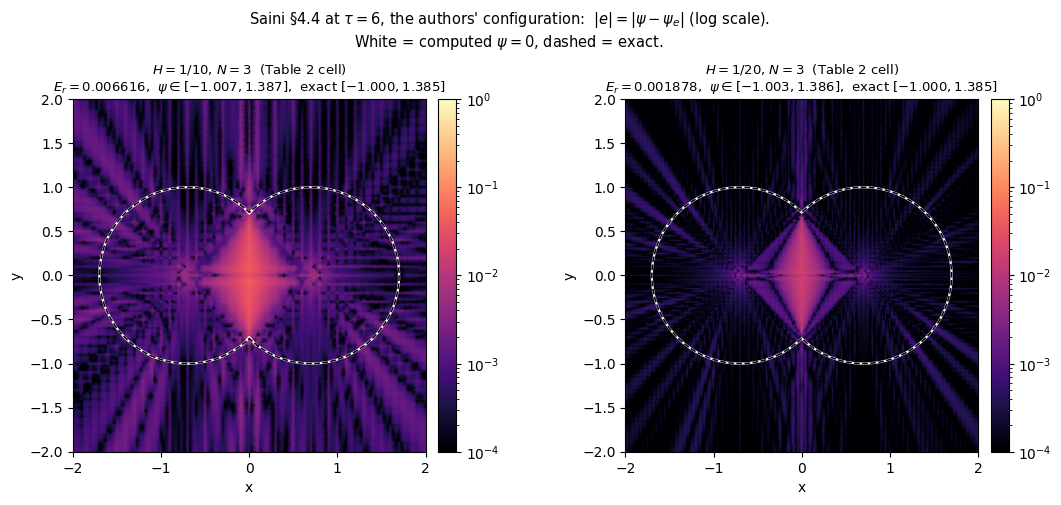

In [2]:
from matplotlib.colors import LogNorm

PANELS = [("output_circles_h10_n3", r"$H = 1/10$, $N = 3$  (Table 2 cell)"),
          ("output_circles_h20_n3", r"$H = 1/20$, $N = 3$  (Table 2 cell)")]

fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.0))
for ax, (d, label) in zip(axes, PANELS):
    tri, psi, pe, er = load(d)
    c = ax.tripcolor(tri, np.maximum(np.abs(psi - pe), 1e-4), shading="gouraud",
                     cmap="magma", norm=LogNorm(1e-4, 1.0))
    ax.tricontour(tri, psi, levels=[0.0], colors="w", linewidths=1.6)
    ax.tricontour(tri, pe, levels=[0.0], colors="k", linewidths=1.1,
                  linestyles="--")
    ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title(label + "\n" +
                 r"$E_r = %.4g$,  $\psi \in [%.3f, %.3f]$,  exact $[-1.000, 1.385]$"
                 % (er, psi.min(), psi.max()),
                 fontsize=9.5)
    fig.colorbar(c, ax=ax, fraction=0.046, pad=0.03)
fig.suptitle(r"Saini §4.4 at $\tau=6$, the authors' configuration:  "
             r"$|e| = |\psi - \psi_e|$ (log scale)."
             "\n" r"White = computed $\psi=0$, dashed = exact.", fontsize=10.5)
fig.tight_layout()